# Bubble Stability and Policy — Lu (2015) Section 4

This notebook replicates Section 4 of:

- **Lu (2015)** "Bubbles in a Secular Stagnation Economy"

Three main results are covered:
1. **Stability**: a bubble is sustainable iff its size is below the loan-market surplus at $r = g$.
2. **PAYG fiscal policy**: a pay-as-you-go transfer crowds out the bubble one-for-one.
3. **Monetary policy neutrality**: changing the inflation target shifts $(Y, \Pi)$ but not the bubble size.

Sections:
1. [Setup](#1-Setup)
2. [Sanity Checks](#2-Sanity-Checks)
3. [Stability Margin Diagram](#3-Stability-Margin-Diagram)
4. [Critical Shock Diagrams](#4-Critical-Shock-Diagrams)
5. [PAYG Transfer Diagram](#5-PAYG-Transfer-Diagram)
6. [Monetary Policy Ineffectiveness](#6-Monetary-Policy-Ineffectiveness)

---
## 1  Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import src.calibration as cal

from src.endowment_model import bubble_upper_bound, fundamental_rate
from src.production_model import (
    potential_output, natural_rate_production, find_equilibrium,
)
from src.stability import (
    bubble_upper_bound_with_old_income,
    stability_margin,
    critical_shock_D,
    critical_shock_Y,
    payg_transfer_effect,
    monetary_policy_effect,
)

FIG_DIR = os.path.join(os.path.dirname(os.getcwd()), 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Convenience aliases
BETA    = cal.BETA
D_H     = cal.D
D_L     = cal.D_L
G       = cal.G
Y_O     = cal.Y_O
ALPHA   = cal.ALPHA
L_BAR   = cal.L_BAR
GAMMA   = cal.GAMMA
PHI_PI  = cal.PHI_PI
PI_STAR = cal.PI_STAR
I_STAR  = cal.I_STAR

Y_F = potential_output(L_BAR, ALPHA)

# Proposition 1 A_max (used for bubble sizes in stability/policy experiments)
A_MAX = bubble_upper_bound(Y_F, D_L, BETA)
# Section 4 A_max (used as the x-axis limit of the stability margin diagram)
A_MAX_SEC4 = bubble_upper_bound_with_old_income(Y_F, Y_O, D_L, G, BETA, r=G)

# Fundamental natural rate (no bubble) at D_L
R_F = fundamental_rate(D_L, G, Y_F, Y_O, BETA)
r_f = R_F - 1.0

print(f'Y_F={Y_F:.4f},  A_MAX (Prop 1)={A_MAX:.4f},  A_MAX (Sec 4)={A_MAX_SEC4:.4f}')
print(f'r^f (fundamental, D_L) = {r_f:.4f}')

Y_F=1.0000,  A_MAX (Prop 1)=0.0634,  A_MAX (Sec 4)=0.0634
r^f (fundamental, D_L) = -0.0358


---
## 2  Sanity Checks

In [2]:
# --- A_max comparison ---------------------------------------------------
print('A_max formulas at D_L')
a_prop1 = bubble_upper_bound(Y_F, D_L, BETA)
a_sec4  = bubble_upper_bound_with_old_income(Y_F, Y_O, D_L, G, BETA, r=G)
print(f'  endowment_model (corrected): {a_prop1:.4f}')
print(f'  stability Sec 4:             {a_sec4:.4f}')
print(f'  Match: {abs(a_prop1 - a_sec4) < 1e-8}')
print()
print('  Both formulas agree with Y_o=0: A_max = (beta*Y_m - (1+2*beta)*D) / (1+beta)')
print('  Note: src/endowment_model.py was corrected from (2+beta) to (1+2*beta).')

A_max formulas at D_L
  endowment_model (corrected): 0.0634
  stability Sec 4:             0.0634
  Match: True

  Both formulas agree with Y_o=0: A_max = (beta*Y_m - (1+2*beta)*D) / (1+beta)
  Note: src/endowment_model.py was corrected from (2+beta) to (1+2*beta).


In [3]:
# --- Stability margins (Section 4 formula) --------------------------------
print('Stability margins at D_L, g=0.2 (Section 4 formula):')
for A_test, label in [(0.0, 'A=0'), (A_MAX/2, 'A=A_max/2'), (A_MAX, 'A=A_max')]:
    m = stability_margin(A_test, Y_F, D_L, BETA, Y_O, g=G)
    print(f'  {label:12s}  ({A_test:.4f}):  margin = {m:.4f}')

Stability margins at D_L, g=0.2 (Section 4 formula):
  A=0           (0.0000):  margin = 0.0634
  A=A_max/2     (0.0317):  margin = 0.0317
  A=A_max       (0.0634):  margin = -0.0000


In [4]:
# --- Critical shocks (Proposition 1 inversion) ----------------------------
print('Critical collateral D_crit (Proposition 1):')
for A_test, label in [(A_MAX/2, 'A_max/2'), (A_MAX, 'A_max')]:
    Dc = critical_shock_D(A_test, Y_F, BETA)
    print(f'  {label}: D_crit = {Dc:.4f}  '
          f'(bubble collapses if D rises above this)')

print()
print('Critical income Y_crit (Proposition 1):')
for A_test, label in [(A_MAX/2, 'A_max/2'), (A_MAX, 'A_max')]:
    Yc = critical_shock_Y(A_test, D_L, BETA)
    print(f'  {label}: Y_crit = {Yc:.4f}  '
          f'(bubble collapses if Y_m falls below this)')

Critical collateral D_crit (Proposition 1):
  A_max/2: D_crit = 0.2577  (bubble collapses if D rises above this)
  A_max: D_crit = 0.2375  (bubble collapses if D rises above this)

Critical income Y_crit (Proposition 1):
  A_max/2: Y_crit = 1.0045  (bubble collapses if Y_m falls below this)
  A_max: Y_crit = 1.0774  (bubble collapses if Y_m falls below this)


---
## 3  Stability Margin Diagram

The stability margin $A_{\max} - A$ falls linearly with bubble size $A$.
At $A = A_{\max}^{\text{Sec4}}$ the margin reaches zero and the bubble collapses.
The Proposition 1 calibration points ($A_{\max}/2$, $A_{\max}$) are marked.

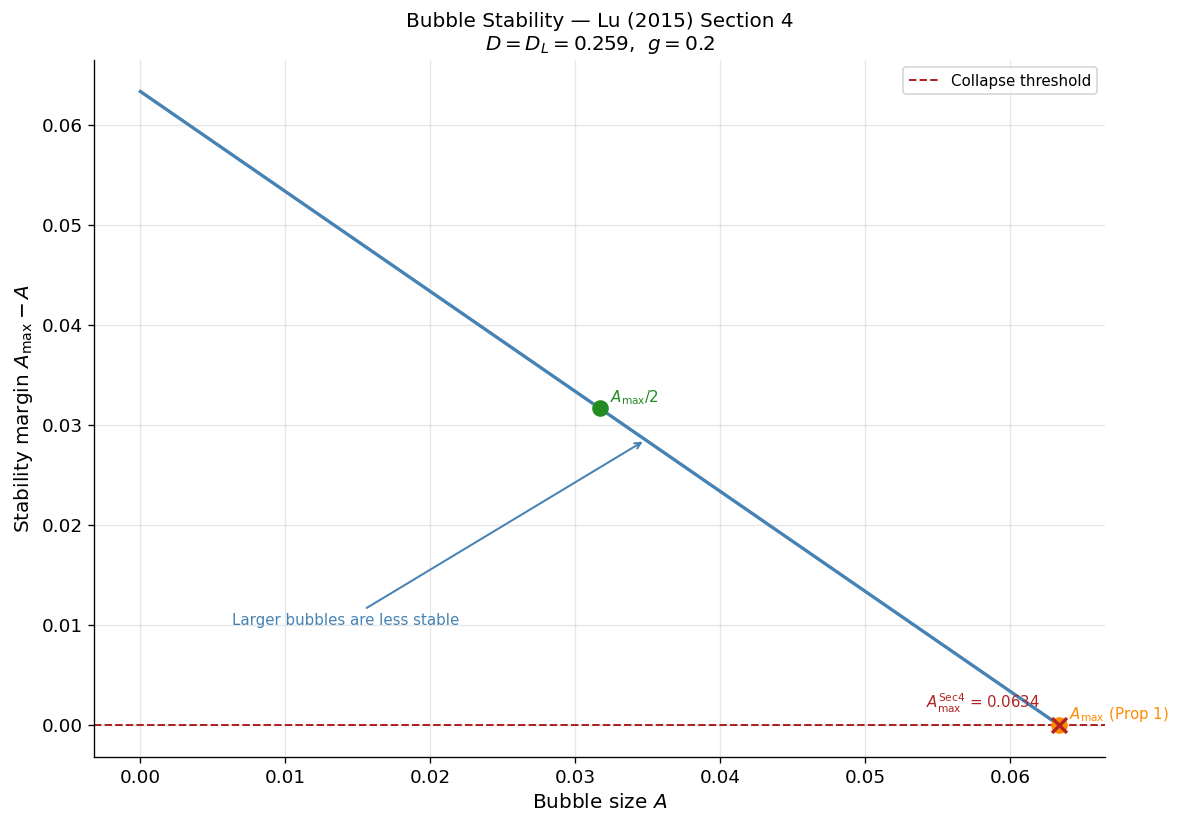

Saved: figures/fig6_stability_margin.{pdf,png}


In [5]:
A_grid  = np.linspace(0.0, A_MAX_SEC4, 400)
margins = np.array([stability_margin(A, Y_F, D_L, BETA, Y_O, g=G)
                    for A in A_grid])

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(A_grid, margins, color='steelblue', lw=2)
ax.axhline(0.0, color='firebrick', lw=1.2, ls='--', label='Collapse threshold')

# Mark A_max/2 and A_max (Prop 1)
for A_mark, label, color in [
    (A_MAX / 2, r'$A_{\max}/2$',    'forestgreen'),
    (A_MAX,     r'$A_{\max}$ (Prop 1)', 'darkorange'),
]:
    m_mark = stability_margin(A_mark, Y_F, D_L, BETA, Y_O, g=G)
    ax.scatter([A_mark], [m_mark], color=color, zorder=5, s=80)
    ax.annotate(label, (A_mark, m_mark),
                textcoords='offset points', xytext=(6, 4),
                fontsize=9, color=color)

# Mark A_max_sec4 (zero crossing)
ax.scatter([A_MAX_SEC4], [0.0], color='firebrick', zorder=5, s=80,
           marker='x', linewidths=2)
ax.annotate(r'$A_{\max}^{\mathrm{Sec4}}$' + f' = {A_MAX_SEC4:.4f}',
            (A_MAX_SEC4, 0.0),
            textcoords='offset points', xytext=(-80, 10),
            fontsize=9, color='firebrick')

# Annotation
ax.annotate('Larger bubbles are less stable',
            xy=(A_MAX_SEC4 * 0.55, stability_margin(A_MAX_SEC4 * 0.55, Y_F, D_L, BETA, Y_O, g=G)),
            xytext=(A_MAX_SEC4 * 0.1, 0.01),
            fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))

ax.set_xlabel('Bubble size $A$', fontsize=12)
ax.set_ylabel('Stability margin $A_{\\max} - A$', fontsize=12)
ax.set_title('Bubble Stability — Lu (2015) Section 4\n'
             f'$D = D_L = {D_L}$,  $g = {G}$', fontsize=12)
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig6_stability_margin.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig6_stability_margin.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig6_stability_margin.{pdf,png}')

---
## 4  Critical Shock Diagrams

A tighter collateral constraint (higher $D$) or a lower middle-aged income
($Y_m$) both erode the stability margin.  The vertical dashed lines mark the
critical values at which the bubble of size $A = A_{\max}/2$ collapses.

A_test = A_MAX/2 = 0.0317
D_zero (margin=0): 0.2811
Y_zero (margin=0): 0.9274


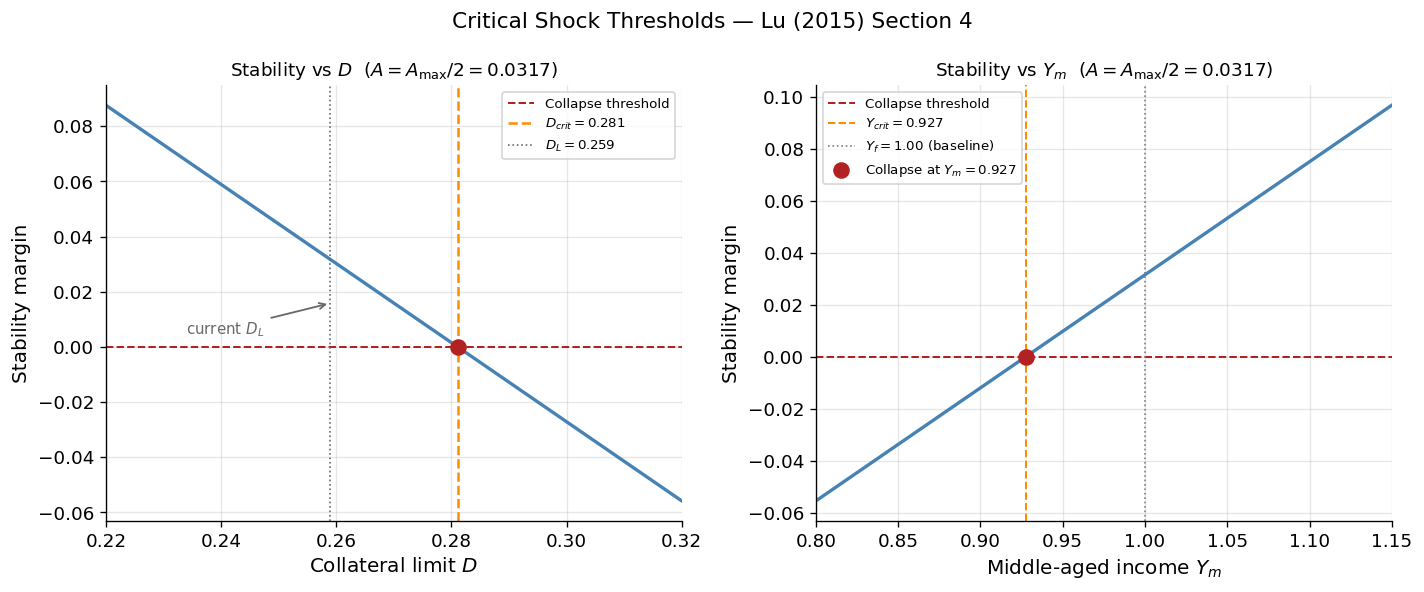

Saved: figures/fig7_critical_shocks.{pdf,png}


In [6]:
A_TEST = A_MAX / 2    # bubble size held fixed for both panels

# --- Find zero crossings numerically via stability_margin ---
D_fine   = np.linspace(0.15, 0.40, 2000)
marg_D   = np.array([stability_margin(A_TEST, Y_F, D, BETA, Y_O, g=G)
                     for D in D_fine])
D_zero   = D_fine[np.where(marg_D >= 0)[0][-1]]

Y_fine   = np.linspace(0.60, 1.40, 2000)
marg_Y   = np.array([stability_margin(A_TEST, Y, D_L, BETA, Y_O, g=G)
                     for Y in Y_fine])
Y_zero   = Y_fine[np.where(marg_Y >= 0)[0][0]]

print(f'A_test = A_MAX/2 = {A_TEST:.4f}')
print(f'D_zero (margin=0): {D_zero:.4f}')
print(f'Y_zero (margin=0): {Y_zero:.4f}')

D_XLIM = (0.22, 0.32)
Y_XLIM = (0.80, 1.15)

D_plot = np.linspace(D_XLIM[0], D_XLIM[1], 500)
Y_plot = np.linspace(Y_XLIM[0], Y_XLIM[1], 500)

marg_D_plot = np.array([stability_margin(A_TEST, Y_F, D, BETA, Y_O, g=G) for D in D_plot])
marg_Y_plot = np.array([stability_margin(A_TEST, Y,   D_L, BETA, Y_O, g=G) for Y in Y_plot])

# Margin at D_L (for arrow annotation tip)
m_at_DL = stability_margin(A_TEST, Y_F, D_L, BETA, Y_O, g=G)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: margin vs D ---
ax1.plot(D_plot, marg_D_plot, color='steelblue', lw=2)
ax1.axhline(0.0, color='firebrick', lw=1.2, ls='--', label='Collapse threshold')
ax1.axvline(D_zero, color='darkorange', lw=1.5, ls='--',
            label=f'$D_{{crit}} = {D_zero:.3f}$')
ax1.axvline(D_L, color='dimgrey', lw=1.0, ls=':',
            label=f'$D_L = {D_L}$')
ax1.scatter([D_zero], [0.0], color='firebrick', zorder=6, s=80)

# Arrow annotation pointing to D_L line
ax1.annotate('current $D_L$',
             xy=(D_L, m_at_DL * 0.5),
             xytext=(D_L - 0.025, m_at_DL * 0.15),
             fontsize=9, color='dimgrey',
             arrowprops=dict(arrowstyle='->', color='dimgrey', lw=1.1))

ax1.set_xlim(*D_XLIM)
ax1.set_xlabel('Collateral limit $D$', fontsize=12)
ax1.set_ylabel('Stability margin', fontsize=12)
ax1.set_title(f'Stability vs $D$  ($A = A_{{\\max}}/2 = {A_TEST:.4f}$)', fontsize=11)
ax1.legend(fontsize=8)

# --- Right: margin vs Y_m ---
ax2.plot(Y_plot, marg_Y_plot, color='steelblue', lw=2)
ax2.axhline(0.0, color='firebrick', lw=1.2, ls='--', label='Collapse threshold')
ax2.axvline(Y_zero, color='darkorange', lw=1.2, ls='--',
            label=f'$Y_{{crit}} = {Y_zero:.3f}$')
ax2.axvline(Y_F, color='grey', lw=1.0, ls=':',
            label=f'$Y_f = {Y_F:.2f}$ (baseline)')
ax2.scatter([Y_zero], [0.0], color='firebrick', zorder=6, s=80,
            label=f'Collapse at $Y_m={Y_zero:.3f}$')
ax2.set_xlim(*Y_XLIM)
ax2.set_xlabel('Middle-aged income $Y_m$', fontsize=12)
ax2.set_ylabel('Stability margin', fontsize=12)
ax2.set_title(f'Stability vs $Y_m$  ($A = A_{{\\max}}/2 = {A_TEST:.4f}$)', fontsize=11)
ax2.legend(fontsize=8)

fig.suptitle('Critical Shock Thresholds — Lu (2015) Section 4', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig7_critical_shocks.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig7_critical_shocks.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig7_critical_shocks.{pdf,png}')

---
## 5  PAYG Transfer Diagram

A PAYG transfer of size $Q$ levied on the middle-aged crowds out the bubble
one-for-one.  As $Q$ rises from 0 to $A_{\max}$, the effective bubble shrinks
and the natural rate $r^n$ falls back toward the fundamental rate $r^f$,
returning the economy to secular stagnation.

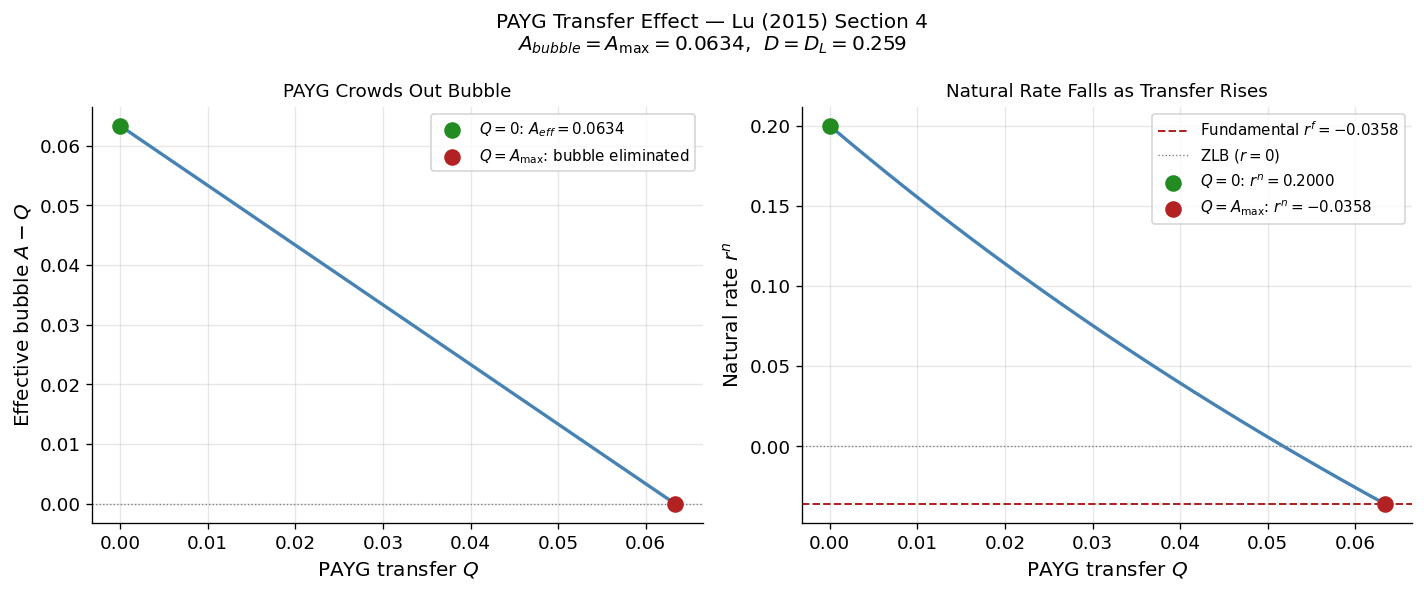

Saved: figures/fig8_payg_transfer.{pdf,png}


In [7]:
Q_vals   = np.linspace(0.0, A_MAX, 200)
payg_res = [payg_transfer_effect(Q, A_MAX, Y_F, D_L, G, BETA) for Q in Q_vals]

A_eff_vals = np.array([p['A_effective'] for p in payg_res])
r_n_vals   = np.array([p['r_natural']   for p in payg_res])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: effective bubble vs Q ---
ax1.plot(Q_vals, A_eff_vals, color='steelblue', lw=2)
ax1.scatter([0.0],    [A_MAX], color='forestgreen', zorder=5, s=80,
            label=f'$Q=0$: $A_{{eff}}={A_MAX:.4f}$')
ax1.scatter([A_MAX],  [0.0],   color='firebrick',   zorder=5, s=80,
            label=f'$Q=A_{{\\max}}$: bubble eliminated')
ax1.axhline(0.0, color='grey', lw=0.8, ls=':')
ax1.set_xlabel('PAYG transfer $Q$', fontsize=12)
ax1.set_ylabel('Effective bubble $A - Q$', fontsize=12)
ax1.set_title('PAYG Crowds Out Bubble', fontsize=11)
ax1.legend(fontsize=9)

# --- Right: r^n vs Q ---
ax2.plot(Q_vals, r_n_vals, color='steelblue', lw=2)
ax2.axhline(r_f, color='firebrick', lw=1.2, ls='--',
            label=f'Fundamental $r^f = {r_f:.4f}$')
ax2.axhline(0.0, color='grey', lw=0.8, ls=':', label='ZLB ($r=0$)')
ax2.scatter([0.0],   [r_n_vals[0]],   color='forestgreen', zorder=5, s=80,
            label=f'$Q=0$: $r^n={r_n_vals[0]:.4f}$')
ax2.scatter([A_MAX], [r_n_vals[-1]],  color='firebrick',   zorder=5, s=80,
            label=f'$Q=A_{{\\max}}$: $r^n={r_n_vals[-1]:.4f}$')
ax2.set_xlabel('PAYG transfer $Q$', fontsize=12)
ax2.set_ylabel('Natural rate $r^n$', fontsize=12)
ax2.set_title('Natural Rate Falls as Transfer Rises', fontsize=11)
ax2.legend(fontsize=9)

fig.suptitle('PAYG Transfer Effect — Lu (2015) Section 4\n'
             f'$A_{{bubble}} = A_{{\\max}} = {A_MAX:.4f}$,  $D = D_L = {D_L}$',
             fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig8_payg_transfer.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig8_payg_transfer.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig8_payg_transfer.{pdf,png}')

---
## 6  Monetary Policy Ineffectiveness

Changing the inflation target $\Pi^*$ shifts the $(Y, \Pi)$ equilibrium
but cannot alter the bubble size $A$, which is determined solely by the
loan-market surplus at $r = g$.

Equilibria across inflation targets (A=0, secular stagnation):
 Pi_star      Y_eq     Pi_eq    regime
   1.000    0.9182    0.9227       zlb
   1.015    0.9182    0.9227       zlb
   1.030    0.9182    0.9227       zlb
   1.045    0.9182    0.9227       zlb
   1.060    0.9182    0.9227       zlb


<>:36: SyntaxWarning: invalid escape sequence '\P'
<>:44: SyntaxWarning: invalid escape sequence '\P'
<>:45: SyntaxWarning: invalid escape sequence '\P'
<>:46: SyntaxWarning: invalid escape sequence '\P'
<>:52: SyntaxWarning: invalid escape sequence '\P'
<>:36: SyntaxWarning: invalid escape sequence '\P'
<>:44: SyntaxWarning: invalid escape sequence '\P'
<>:45: SyntaxWarning: invalid escape sequence '\P'
<>:46: SyntaxWarning: invalid escape sequence '\P'
<>:52: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_136591/2301931409.py:36: SyntaxWarning: invalid escape sequence '\P'
  ax1.set_xlabel('Inflation target $\Pi^*$', fontsize=12)
/tmp/ipykernel_136591/2301931409.py:44: SyntaxWarning: invalid escape sequence '\P'
  label='$\Pi = \Pi^*$ (on-target)')
/tmp/ipykernel_136591/2301931409.py:45: SyntaxWarning: invalid escape sequence '\P'
  ax2.set_xlabel('Inflation target $\Pi^*$', fontsize=12)
/tmp/ipykernel_136591/2301931409.py:46: SyntaxWarning: invalid escape sequence '\P'
 

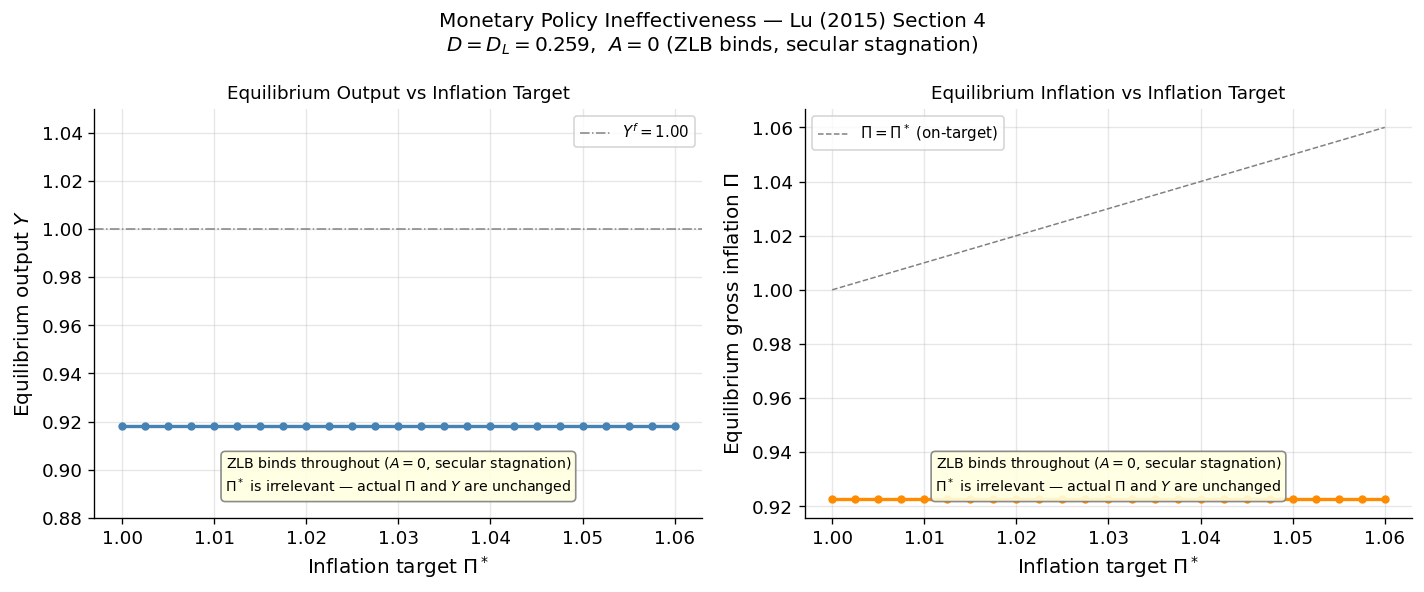

Saved: figures/fig9_monetary_policy.{pdf,png}


In [8]:
# Monetary policy ineffectiveness: use A=0 (secular stagnation, ZLB binds).
# At A=A_max/2 the bubble lifts r^n above zero, so the ZLB no longer binds
# and monetary policy IS effective. The neutrality result applies when the
# ZLB is binding — i.e. in the secular stagnation equilibrium (A=0).
# Sweep Pi_star from 1.00 to 1.06; the ZLB binds throughout this range.

PI_TARGETS = np.linspace(1.00, 1.06, 25)
A_MP       = 0.0     # secular stagnation — no bubble

Y_equil  = []
Pi_equil = []
regimes  = []

for Pi_t in PI_TARGETS:
    eq = find_equilibrium(D_L, G, BETA, PHI_PI, Pi_t, I_STAR,
                          GAMMA, ALPHA, L_BAR, A_bubble=A_MP)
    Y_equil.append(eq['Y'])
    Pi_equil.append(eq['Pi'])
    regimes.append(eq['regime'])

Y_equil  = np.array(Y_equil)
Pi_equil = np.array(Pi_equil)

print('Equilibria across inflation targets (A=0, secular stagnation):')
print(f'{"Pi_star":>8}  {"Y_eq":>8}  {"Pi_eq":>8}  {"regime":>8}')
for Pi_t, Y_e, Pi_e, reg in zip(PI_TARGETS[::6], Y_equil[::6],
                                  Pi_equil[::6], regimes[::6]):
    print(f'{Pi_t:8.3f}  {Y_e:8.4f}  {Pi_e:8.4f}  {reg:>8}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: equilibrium Y vs Pi_star ---
ax1.plot(PI_TARGETS, Y_equil, color='steelblue', lw=2, marker='o', ms=4)
ax1.axhline(Y_F, color='grey', lw=0.9, ls='-.', label=f'$Y^f = {Y_F:.2f}$')
ax1.set_ylim(0.88, 1.05)
ax1.set_xlabel('Inflation target $\Pi^*$', fontsize=12)
ax1.set_ylabel('Equilibrium output $Y$', fontsize=12)
ax1.set_title('Equilibrium Output vs Inflation Target', fontsize=11)
ax1.legend(fontsize=9)

# --- Right: equilibrium Pi vs Pi_star ---
ax2.plot(PI_TARGETS, Pi_equil, color='darkorange', lw=2, marker='o', ms=4)
ax2.plot(PI_TARGETS, PI_TARGETS, color='grey', lw=0.9, ls='--',
         label='$\Pi = \Pi^*$ (on-target)')
ax2.set_xlabel('Inflation target $\Pi^*$', fontsize=12)
ax2.set_ylabel('Equilibrium gross inflation $\Pi$', fontsize=12)
ax2.set_title('Equilibrium Inflation vs Inflation Target', fontsize=11)
ax2.legend(fontsize=9)

# Shared annotation: ZLB binds, Pi_star is irrelevant
box_text = ('ZLB binds throughout ($A=0$, secular stagnation)\n'
            '$\Pi^*$ is irrelevant — actual $\Pi$ and $Y$ are unchanged')
for ax in (ax1, ax2):
    ax.text(0.5, 0.05, box_text,
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=8.5, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='grey', alpha=0.9))

fig.suptitle('Monetary Policy Ineffectiveness — Lu (2015) Section 4\n'
             f'$D = D_L = {D_L}$,  $A = 0$ (ZLB binds, secular stagnation)',
             fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig9_monetary_policy.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig9_monetary_policy.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig9_monetary_policy.{pdf,png}')